Saving Asal_LR_01_rppg_input_20260603_182312.avi to Asal_LR_01_rppg_input_20260603_182312.avi
Uploaded video: Asal_LR_01_rppg_input_20260603_182312.avi
Video FPS: 30.0
Extracted samples: 653
Preview frames:
Green rectangle = face
Red rectangle = forehead
Blue rectangles = cheeks


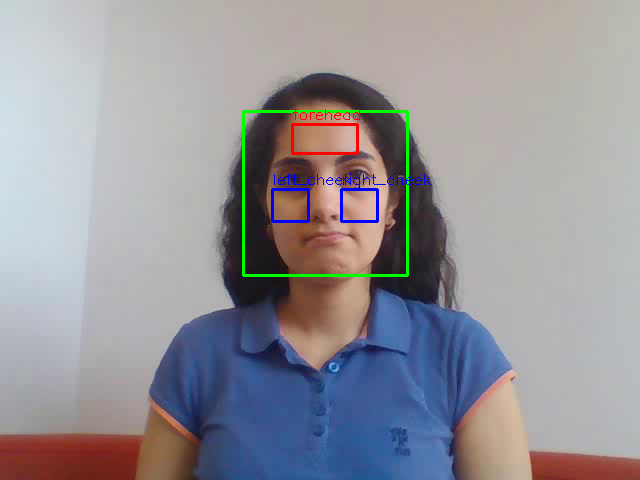

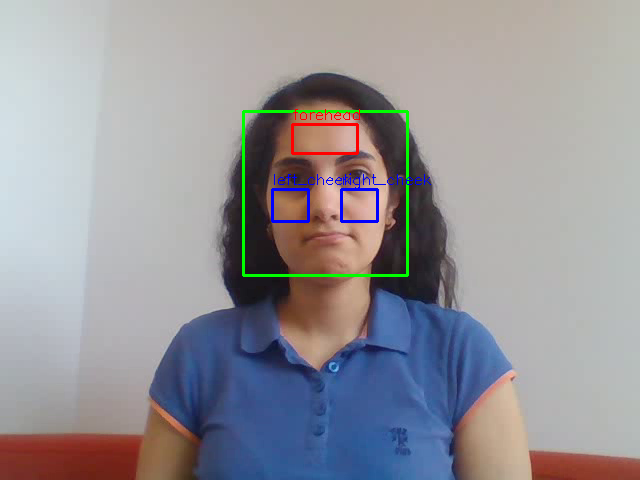

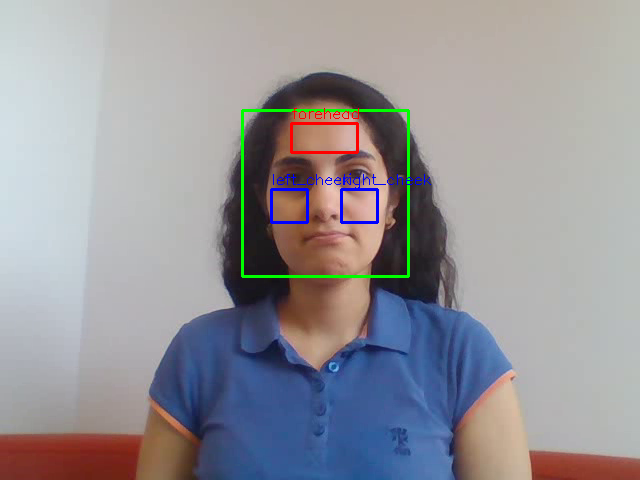

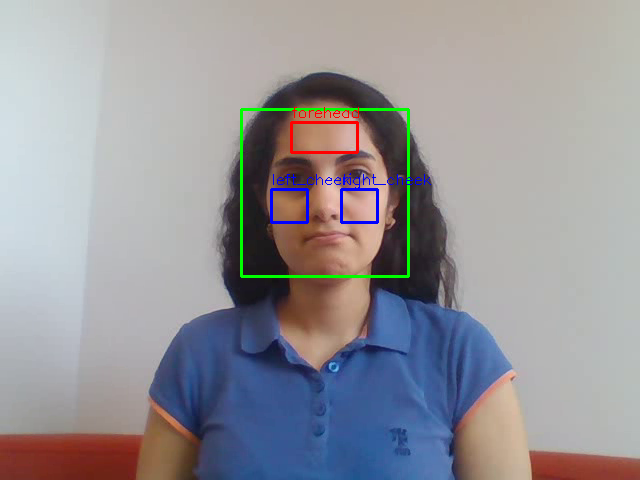

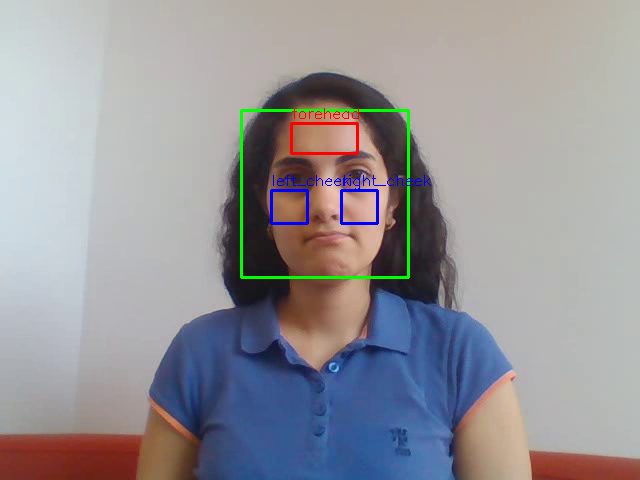

Estimated sampling rate: 22.665121668597916

===== Smart Green-only rPPG Results =====
HR Green FFT: 75.42 bpm
HR Green Peak: 75.55 bpm

===== Smart POS rPPG Results =====
HR POS FFT: 75.22 bpm
HR POS Peak: 75.55 bpm

===== Consensus Result =====
Final Consensus HR: 75.32 bpm
Peak Guidance HR: 75.55 bpm
Motion Peak Correction Applied: False
Left-Right Candidate Correction Applied: False
Left-Right Low-Lock Rescue Applied: False

Green FFT Debug
Full best: 75.41528751342082
Window HR: 75.37554378610444
Window median: 74.497655701839
Window MAD: 1.579847770714835
Reliability: 0.48163368482169105
Top FFT candidates:
1. 75.42 bpm | mag=41.814 | norm=1.000
2. 62.18 bpm | mag=17.110 | norm=0.409

POS FFT Debug
Full best: 72.86281785948592
Window HR: 75.21658973427387
Window median: 75.46686574892452
Window MAD: 2.518663267451167
Reliability: 0.35150888338817965
Top FFT candidates:
1. 72.86 bpm | mag=21.194 | norm=1.000
2. 79.09 bpm | mag=20.139 | norm=0.950
3. 62.25 bpm | mag=14.252 | norm=0

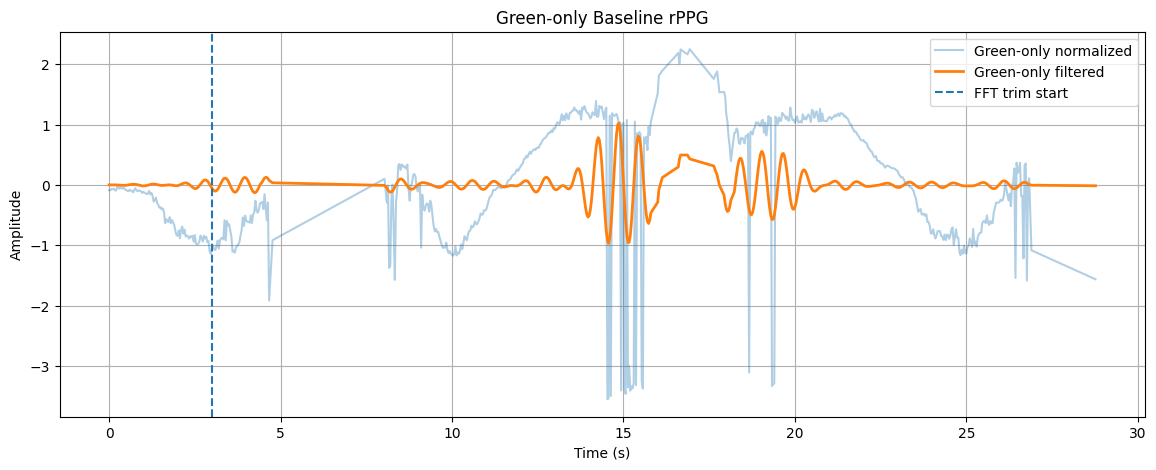

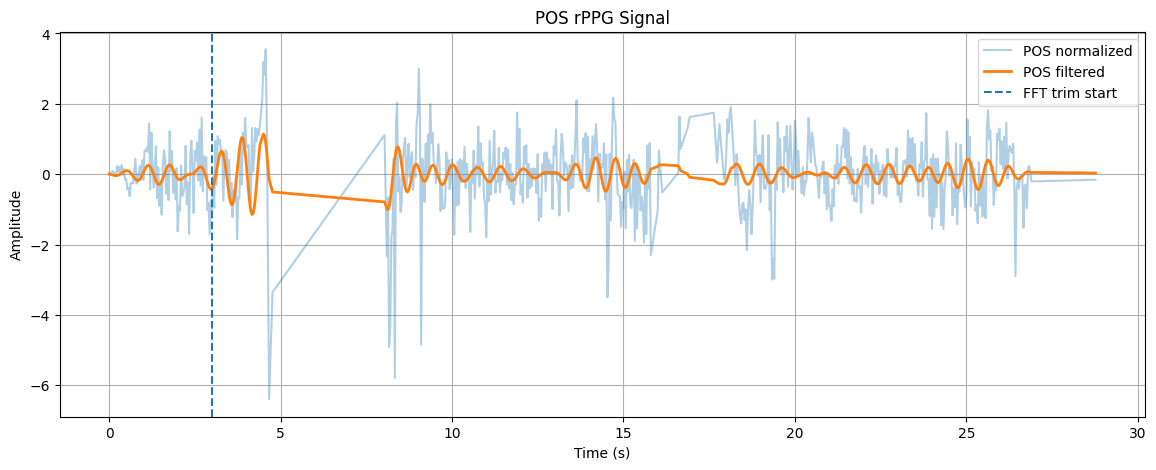

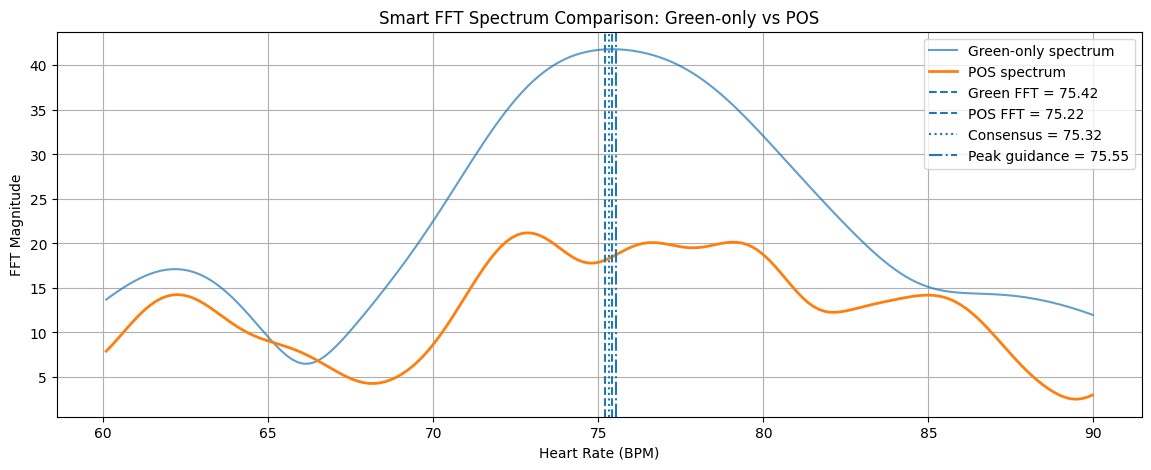

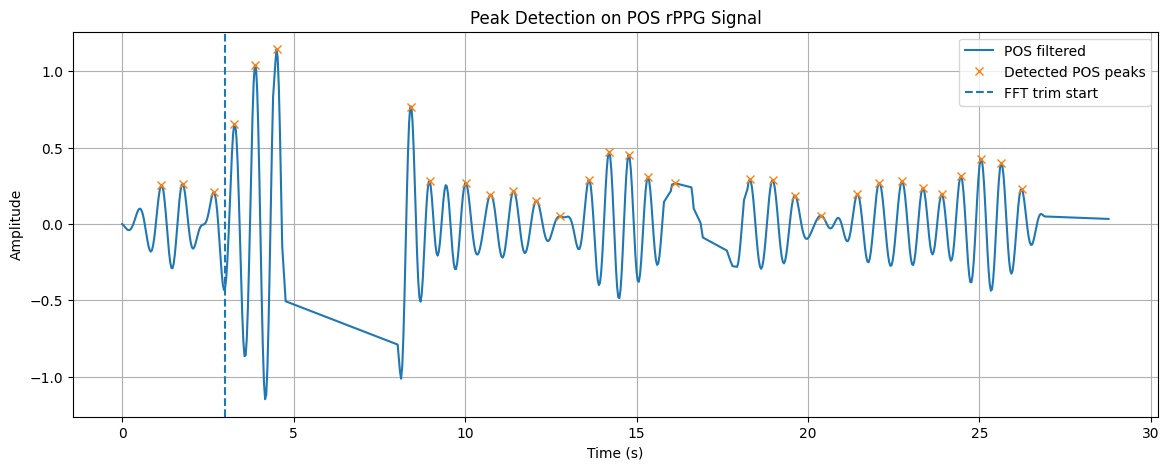

In [29]:
# =========================
# Final Smart Multi-ROI + POS rPPG for Google Colab
# Offline video version
# No real HR required
#
# Features:
# - Multi-ROI RGB extraction
# - POS rPPG
# - Zero-padded FFT
# - Parabolic peak interpolation
# - Window stability
# - Green/POS consensus
# - Peak agreement correction
# - Safer high-HR rescue rule
# - Safer POS-dominant high-HR rescue
# - Motion-mode peak guidance correction
# - Left-right candidate guidance correction
# - Left-right low-lock rescue correction
# =========================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, detrend
from google.colab.patches import cv2_imshow
from google.colab import files


# =========================
# Upload video
# =========================
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print("Uploaded video:", video_path)


# =========================
# Global settings
# =========================
MIN_BPM = 60
MAX_BPM = 90

TRIM_START_SECONDS = 3.0

POS_WINDOW_SECONDS = 1.6

WINDOW_SECONDS = 12.0
WINDOW_STEP_SECONDS = 2.0

FFT_TOP_N_PEAKS = 8
FFT_ZERO_PADDING_FACTOR = 8


# =========================
# Basic signal functions
# =========================
def normalize_signal(signal):
    signal = np.asarray(signal, dtype=float)
    mean = np.mean(signal)
    std = np.std(signal)

    if std < 1e-8:
        return signal - mean

    return (signal - mean) / std


def bandpass_filter(signal, fs, min_bpm=60, max_bpm=90, order=4):
    signal = np.asarray(signal, dtype=float)

    low_hz = min_bpm / 60.0
    high_hz = max_bpm / 60.0

    try:
        b, a = butter(order, [low_hz, high_hz], btype="bandpass", fs=fs)

        padlen = 3 * max(len(a), len(b))
        if len(signal) <= padlen:
            return signal

        return filtfilt(b, a, signal)

    except Exception as e:
        print("[Filter warning]", e)
        return signal


def trim_signal_start(signal, fs, trim_start_seconds=3.0):
    signal = np.asarray(signal, dtype=float)
    trim_samples = int(trim_start_seconds * fs)

    if len(signal) > trim_samples + int(fs * 6):
        return signal[trim_samples:]

    return signal


def next_power_of_two(n):
    return int(2 ** np.ceil(np.log2(max(1, n))))


def parabolic_interpolation(y, index):
    if index <= 0 or index >= len(y) - 1:
        return 0.0

    y0 = y[index - 1]
    y1 = y[index]
    y2 = y[index + 1]

    denominator = y0 - 2.0 * y1 + y2

    if abs(denominator) < 1e-12:
        return 0.0

    delta = 0.5 * (y0 - y2) / denominator
    delta = float(np.clip(delta, -0.5, 0.5))

    return delta


def compute_fft_spectrum(
    signal,
    fs,
    min_bpm=60,
    max_bpm=90,
    trim_start_seconds=3.0,
    zero_padding_factor=8
):
    signal = np.asarray(signal, dtype=float)
    signal = trim_signal_start(signal, fs, trim_start_seconds)

    if len(signal) < int(fs * 6):
        return None, None

    signal = signal - np.mean(signal)
    signal = signal * np.hanning(len(signal))

    n_fft = next_power_of_two(len(signal)) * zero_padding_factor

    freqs = np.fft.rfftfreq(n_fft, d=1.0 / fs)
    spectrum = np.abs(np.fft.rfft(signal, n=n_fft))

    bpm_axis = freqs * 60.0
    mask = (bpm_axis >= min_bpm) & (bpm_axis <= max_bpm)

    if not np.any(mask):
        return None, None

    return bpm_axis[mask], spectrum[mask]


def refined_peak_bpm(bpm_axis, spectrum, peak_index):
    if bpm_axis is None or spectrum is None:
        return None

    if len(bpm_axis) < 2:
        return float(bpm_axis[peak_index])

    bpm_step = bpm_axis[1] - bpm_axis[0]

    safe_spectrum = np.maximum(spectrum, 1e-12)
    log_spectrum = np.log(safe_spectrum)

    delta = parabolic_interpolation(log_spectrum, peak_index)
    refined_bpm = bpm_axis[peak_index] + delta * bpm_step

    return float(refined_bpm)


def get_fft_candidates(
    signal,
    fs,
    min_bpm=60,
    max_bpm=90,
    trim_start_seconds=3.0,
    top_n_peaks=8
):
    bpm_axis, spectrum = compute_fft_spectrum(
        signal,
        fs,
        min_bpm=min_bpm,
        max_bpm=max_bpm,
        trim_start_seconds=trim_start_seconds,
        zero_padding_factor=FFT_ZERO_PADDING_FACTOR
    )

    if bpm_axis is None or spectrum is None or len(spectrum) == 0:
        return []

    max_mag = np.max(spectrum)

    if max_mag < 1e-8:
        return []

    peak_indices, _ = find_peaks(
        spectrum,
        distance=2,
        prominence=0.03 * max_mag
    )

    if len(peak_indices) == 0:
        peak_indices = np.array([int(np.argmax(spectrum))])

    peak_mag = spectrum[peak_indices]

    order = np.argsort(peak_mag)[::-1]
    order = order[:top_n_peaks]

    candidates = []

    for idx in order:
        peak_index = int(peak_indices[idx])
        bpm = refined_peak_bpm(bpm_axis, spectrum, peak_index)

        candidates.append({
            "bpm": float(bpm),
            "magnitude": float(spectrum[peak_index]),
            "norm_magnitude": float(spectrum[peak_index] / max_mag)
        })

    return candidates


def estimate_windowed_fft(
    signal,
    fs,
    min_bpm=60,
    max_bpm=90,
    trim_start_seconds=3.0,
    window_seconds=12.0,
    step_seconds=2.0
):
    signal = np.asarray(signal, dtype=float)
    signal = trim_signal_start(signal, fs, trim_start_seconds)

    window_len = int(window_seconds * fs)
    step_len = int(step_seconds * fs)

    if len(signal) < window_len:
        return []

    estimates = []

    for start in range(0, len(signal) - window_len + 1, step_len):
        end = start + window_len
        segment = signal[start:end]

        bpm_axis, spectrum = compute_fft_spectrum(
            segment,
            fs,
            min_bpm=min_bpm,
            max_bpm=max_bpm,
            trim_start_seconds=0.0,
            zero_padding_factor=FFT_ZERO_PADDING_FACTOR
        )

        if bpm_axis is None or spectrum is None or len(spectrum) == 0:
            continue

        max_mag = np.max(spectrum)
        mean_mag = np.mean(spectrum) + 1e-8

        if max_mag < 1e-8:
            continue

        best_idx = int(np.argmax(spectrum))
        best_bpm = refined_peak_bpm(bpm_axis, spectrum, best_idx)
        quality = float(max_mag / mean_mag)

        estimates.append({
            "bpm": float(best_bpm),
            "quality": quality,
            "start_sec": start / fs,
            "end_sec": end / fs
        })

    return estimates


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    if len(values) == 0:
        return None

    if np.sum(weights) < 1e-8:
        return float(np.mean(values))

    return float(np.sum(values * weights) / np.sum(weights))


def robust_window_hr(window_estimates):
    if len(window_estimates) == 0:
        return None, None, None

    bpms = np.asarray([item["bpm"] for item in window_estimates], dtype=float)
    qualities = np.asarray([item["quality"] for item in window_estimates], dtype=float)

    median_hr = float(np.median(bpms))
    mad = float(np.median(np.abs(bpms - median_hr)))

    if len(bpms) >= 3:
        keep_mask = np.abs(bpms - median_hr) <= max(4.0, 1.5 * mad)
        kept_bpms = bpms[keep_mask]
        kept_qualities = qualities[keep_mask]
    else:
        kept_bpms = bpms
        kept_qualities = qualities

    if len(kept_bpms) == 0:
        kept_bpms = bpms
        kept_qualities = qualities

    stable_hr = weighted_mean(kept_bpms, kept_qualities)

    return stable_hr, median_hr, mad


def summarize_channel_fft(
    signal,
    fs,
    min_bpm=60,
    max_bpm=90,
    trim_start_seconds=3.0,
    top_n_peaks=8,
    window_seconds=12.0,
    step_seconds=2.0
):
    candidates = get_fft_candidates(
        signal,
        fs,
        min_bpm=min_bpm,
        max_bpm=max_bpm,
        trim_start_seconds=trim_start_seconds,
        top_n_peaks=top_n_peaks
    )

    window_estimates = estimate_windowed_fft(
        signal,
        fs,
        min_bpm=min_bpm,
        max_bpm=max_bpm,
        trim_start_seconds=trim_start_seconds,
        window_seconds=window_seconds,
        step_seconds=step_seconds
    )

    full_best = None
    if len(candidates) > 0:
        full_best = candidates[0]["bpm"]

    window_hr, window_median, window_mad = robust_window_hr(window_estimates)

    if window_hr is None:
        window_hr = full_best

    window_qualities = [item["quality"] for item in window_estimates]

    if window_mad is None:
        stability_score = 0.0
    else:
        stability_score = 1.0 / (1.0 + window_mad)

    if len(window_qualities) > 0:
        quality_score = float(np.median(window_qualities))
    else:
        quality_score = 0.0

    if len(candidates) >= 2:
        peak_ratio = candidates[0]["magnitude"] / (candidates[1]["magnitude"] + 1e-8)
    else:
        peak_ratio = 1.0

    reliability = float(
        0.45 * stability_score +
        0.35 * min(quality_score / 5.0, 1.0) +
        0.20 * min(peak_ratio / 2.0, 1.0)
    )

    return {
        "candidates": candidates,
        "window_estimates": window_estimates,
        "full_best": full_best,
        "window_hr": window_hr,
        "window_median": window_median,
        "window_mad": window_mad,
        "quality_score": quality_score,
        "peak_ratio": peak_ratio,
        "reliability": reliability
    }


def build_consensus_hr(green_info, pos_info):
    green_window = green_info["window_hr"]
    pos_window = pos_info["window_hr"]
    green_full = green_info["full_best"]
    pos_full = pos_info["full_best"]

    values = []
    weights = []

    if green_window is not None:
        values.append(green_window)
        weights.append(1.0 + green_info["reliability"])

    if pos_window is not None:
        values.append(pos_window)
        weights.append(1.0 + pos_info["reliability"])

    if green_full is not None:
        values.append(green_full)
        weights.append(0.45 + 0.5 * green_info["reliability"])

    if pos_full is not None:
        values.append(pos_full)
        weights.append(0.45 + 0.5 * pos_info["reliability"])

    if len(values) == 0:
        return None

    if green_window is not None and pos_window is not None:
        diff = abs(green_window - pos_window)

        if diff <= 4.0:
            return weighted_mean(
                [green_window, pos_window],
                [1.0 + green_info["reliability"], 1.0 + pos_info["reliability"]]
            )

        if green_info["reliability"] > pos_info["reliability"] + 0.15:
            return float(green_window)

        if pos_info["reliability"] > green_info["reliability"] + 0.15:
            return float(pos_window)

    return weighted_mean(values, weights)


def choose_candidate_near_consensus(channel_info, consensus_hr):
    if consensus_hr is None:
        if channel_info["window_hr"] is not None:
            return channel_info["window_hr"]
        return channel_info["full_best"]

    candidate_bpms = []
    candidate_weights = []

    for candidate in channel_info["candidates"]:
        candidate_bpms.append(candidate["bpm"])
        candidate_weights.append(candidate["norm_magnitude"])

    if channel_info["window_hr"] is not None:
        candidate_bpms.append(channel_info["window_hr"])
        candidate_weights.append(0.95)

    if channel_info["full_best"] is not None:
        candidate_bpms.append(channel_info["full_best"])
        candidate_weights.append(0.75)

    if len(candidate_bpms) == 0:
        return consensus_hr

    candidate_bpms = np.asarray(candidate_bpms, dtype=float)
    candidate_weights = np.asarray(candidate_weights, dtype=float)

    distances = np.abs(candidate_bpms - consensus_hr)
    scores = distances - 2.0 * candidate_weights

    best_idx = int(np.argmin(scores))
    selected = float(candidate_bpms[best_idx])

    if abs(selected - consensus_hr) > 6.0:
        selected = float(consensus_hr)

    return selected


def estimate_smart_fft_pair(
    green_signal,
    pos_signal,
    fs,
    min_bpm=60,
    max_bpm=90,
    trim_start_seconds=3.0
):
    green_info = summarize_channel_fft(
        green_signal,
        fs,
        min_bpm=min_bpm,
        max_bpm=max_bpm,
        trim_start_seconds=trim_start_seconds,
        top_n_peaks=FFT_TOP_N_PEAKS,
        window_seconds=WINDOW_SECONDS,
        step_seconds=WINDOW_STEP_SECONDS
    )

    pos_info = summarize_channel_fft(
        pos_signal,
        fs,
        min_bpm=min_bpm,
        max_bpm=max_bpm,
        trim_start_seconds=trim_start_seconds,
        top_n_peaks=FFT_TOP_N_PEAKS,
        window_seconds=WINDOW_SECONDS,
        step_seconds=WINDOW_STEP_SECONDS
    )

    consensus_hr = build_consensus_hr(green_info, pos_info)

    green_hr = choose_candidate_near_consensus(green_info, consensus_hr)
    pos_hr = choose_candidate_near_consensus(pos_info, consensus_hr)

    return green_hr, pos_hr, consensus_hr, green_info, pos_info


def estimate_hr_peaks(signal, fs, min_bpm=60, max_bpm=90):
    signal = np.asarray(signal, dtype=float)

    if len(signal) < int(fs * 6):
        return None

    signal = signal - np.mean(signal)

    min_distance = max(1, int(fs * 60.0 / max_bpm))
    prominence = max(0.35 * np.std(signal), 0.15)

    peaks, _ = find_peaks(
        signal,
        distance=min_distance,
        prominence=prominence
    )

    if len(peaks) < 2:
        return None

    intervals = np.diff(peaks) / fs
    bpm_values = 60.0 / intervals

    bpm_values = bpm_values[
        (bpm_values >= min_bpm) & (bpm_values <= max_bpm)
    ]

    if len(bpm_values) == 0:
        return None

    return float(np.median(bpm_values))


# =========================
# Final correction rules
# =========================
def adaptive_final_correction(
    green_info,
    pos_info,
    hr_green_fft,
    hr_pos_fft,
    hr_consensus,
    hr_green_peak,
    hr_pos_peak
):
    def get_strong_high_candidate(
        channel_info,
        low_bpm=78.0,
        high_bpm=86.5,
        min_norm=0.70
    ):
        valid_candidates = []

        for candidate in channel_info["candidates"]:
            bpm = candidate["bpm"]
            norm = candidate["norm_magnitude"]

            if low_bpm <= bpm <= high_bpm and norm >= min_norm:
                valid_candidates.append(candidate)

        if len(valid_candidates) == 0:
            return None

        valid_candidates = sorted(
            valid_candidates,
            key=lambda c: c["norm_magnitude"],
            reverse=True
        )

        return valid_candidates[0]

    def is_value_high(value, low_bpm=78.0, high_bpm=86.5):
        if value is None:
            return False
        return low_bpm <= value <= high_bpm

    def get_current_consensus(hr_green_fft, hr_pos_fft, hr_consensus):
        current_values = [
            value for value in [hr_green_fft, hr_pos_fft, hr_consensus]
            if value is not None
        ]

        if len(current_values) == 0:
            return None

        return float(np.median(current_values))

    peak_guidance_hr = None

    green_high_candidate = get_strong_high_candidate(green_info)
    pos_high_candidate = get_strong_high_candidate(pos_info)

    green_full_is_high = is_value_high(green_info["full_best"])
    pos_full_is_high = is_value_high(pos_info["full_best"])
    pos_window_is_high = is_value_high(pos_info["window_hr"])
    pos_median_is_high = is_value_high(pos_info["window_median"])

    current_consensus = get_current_consensus(
        hr_green_fft,
        hr_pos_fft,
        hr_consensus
    )

    # Step 1A: Safer POS-dominant high-HR rescue
    if pos_high_candidate is not None and current_consensus is not None:
        pos_high_bpm = float(pos_high_candidate["bpm"])
        pos_high_norm = float(pos_high_candidate["norm_magnitude"])

        pos_has_high_main_support = (
            pos_full_is_high or
            pos_window_is_high or
            pos_median_is_high
        )

        pos_has_strong_high_evidence = (
            pos_high_norm >= 0.70 and
            pos_high_bpm - current_consensus >= 6.0 and
            pos_has_high_main_support
        )

        green_is_not_strongly_opposing = True

        if green_high_candidate is not None:
            green_high_bpm = float(green_high_candidate["bpm"])
            if abs(green_high_bpm - pos_high_bpm) > 7.0:
                green_is_not_strongly_opposing = False

        peak_does_not_strongly_reject_high = True

        if hr_green_peak is not None and hr_pos_peak is not None:
            peak_guidance_temp = float(np.median([hr_green_peak, hr_pos_peak]))

            if peak_guidance_temp < 74.0 and pos_high_bpm - peak_guidance_temp > 8.0:
                peak_does_not_strongly_reject_high = False

        if (
            pos_has_strong_high_evidence and
            green_is_not_strongly_opposing and
            peak_does_not_strongly_reject_high
        ):
            hr_green_fft = pos_high_bpm
            hr_pos_fft = pos_high_bpm
            hr_consensus = pos_high_bpm
            peak_guidance_hr = None

            return hr_green_fft, hr_pos_fft, hr_consensus, peak_guidance_hr

    # Step 1B: Two-channel high-HR rescue
    if green_high_candidate is not None and pos_high_candidate is not None:
        green_high_bpm = float(green_high_candidate["bpm"])
        pos_high_bpm = float(pos_high_candidate["bpm"])

        high_candidate_diff = abs(green_high_bpm - pos_high_bpm)
        high_candidate_consensus = float(np.median([green_high_bpm, pos_high_bpm]))

        current_consensus = get_current_consensus(
            hr_green_fft,
            hr_pos_fft,
            hr_consensus
        )

        high_full_support = green_full_is_high or pos_full_is_high

        if (
            high_candidate_diff <= 4.0 and
            current_consensus is not None and
            high_candidate_consensus - current_consensus >= 5.0 and
            high_full_support
        ):
            hr_green_fft = green_high_bpm
            hr_pos_fft = pos_high_bpm
            hr_consensus = float(np.median([hr_green_fft, hr_pos_fft]))
            peak_guidance_hr = None

            return hr_green_fft, hr_pos_fft, hr_consensus, peak_guidance_hr

    # Step 2: Peak agreement correction
    if hr_green_peak is not None and hr_pos_peak is not None:
        peak_diff = abs(hr_green_peak - hr_pos_peak)

        if peak_diff <= 3.0:
            peak_guidance_hr = float(np.median([hr_green_peak, hr_pos_peak]))

            if hr_green_fft is not None and abs(hr_green_fft - peak_guidance_hr) > 2.0:
                hr_green_fft = peak_guidance_hr

            if hr_pos_fft is not None and abs(hr_pos_fft - peak_guidance_hr) > 2.0:
                hr_pos_fft = peak_guidance_hr

            if hr_green_fft is not None and hr_pos_fft is not None:
                hr_consensus = float(np.median([hr_green_fft, hr_pos_fft]))

        else:
            peak_guidance_hr = float(np.median([hr_green_peak, hr_pos_peak]))

    elif hr_pos_peak is not None:
        peak_guidance_hr = float(hr_pos_peak)

    elif hr_green_peak is not None:
        peak_guidance_hr = float(hr_green_peak)

    return hr_green_fft, hr_pos_fft, hr_consensus, peak_guidance_hr


def motion_peak_guidance_correction(
    hr_green_fft,
    hr_pos_fft,
    hr_consensus,
    peak_guidance_hr
):
    if peak_guidance_hr is None:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    if hr_green_fft is None or hr_pos_fft is None or hr_consensus is None:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    if not (70.0 <= peak_guidance_hr <= 82.0):
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    both_fft_below_guidance = (
        hr_green_fft < peak_guidance_hr - 4.0 and
        hr_pos_fft < peak_guidance_hr - 4.0
    )

    consensus_far_below_guidance = hr_consensus < peak_guidance_hr - 5.0

    if both_fft_below_guidance and consensus_far_below_guidance:
        corrected_hr = float(peak_guidance_hr)
        return corrected_hr, corrected_hr, corrected_hr, True

    return hr_green_fft, hr_pos_fft, hr_consensus, False


def left_right_candidate_guidance_correction(
    green_info,
    pos_info,
    hr_green_fft,
    hr_pos_fft,
    hr_consensus,
    peak_guidance_hr
):
    if peak_guidance_hr is None:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    if hr_green_fft is None or hr_pos_fft is None or hr_consensus is None:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    if not (70.0 <= peak_guidance_hr <= 80.5):
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    consensus_too_low = hr_consensus < peak_guidance_hr - 4.0

    if not consensus_too_low:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    def find_candidate_near_guidance(channel_info, guidance_hr, tolerance=3.0, min_norm=0.40):
        valid_candidates = []

        for candidate in channel_info["candidates"]:
            bpm = float(candidate["bpm"])
            norm = float(candidate["norm_magnitude"])

            if abs(bpm - guidance_hr) <= tolerance and norm >= min_norm:
                valid_candidates.append(candidate)

        if len(valid_candidates) == 0:
            return None

        valid_candidates = sorted(
            valid_candidates,
            key=lambda c: (
                abs(float(c["bpm"]) - guidance_hr),
                -float(c["norm_magnitude"])
            )
        )

        return valid_candidates[0]

    green_candidate = find_candidate_near_guidance(
        green_info,
        peak_guidance_hr,
        tolerance=3.0,
        min_norm=0.40
    )

    pos_candidate = find_candidate_near_guidance(
        pos_info,
        peak_guidance_hr,
        tolerance=3.0,
        min_norm=0.40
    )

    if green_candidate is not None and pos_candidate is not None:
        green_bpm = float(green_candidate["bpm"])
        pos_bpm = float(pos_candidate["bpm"])

        if abs(green_bpm - pos_bpm) <= 3.0:
            corrected_hr = float(np.median([green_bpm, pos_bpm, peak_guidance_hr]))
            return corrected_hr, corrected_hr, corrected_hr, True

    if pos_candidate is not None:
        pos_bpm = float(pos_candidate["bpm"])
        pos_norm = float(pos_candidate["norm_magnitude"])

        if pos_norm >= 0.55 and abs(pos_bpm - peak_guidance_hr) <= 3.0:
            corrected_hr = float(np.median([pos_bpm, peak_guidance_hr]))
            return corrected_hr, corrected_hr, corrected_hr, True

    return hr_green_fft, hr_pos_fft, hr_consensus, False


def left_right_low_lock_rescue(
    green_info,
    pos_info,
    hr_green_fft,
    hr_pos_fft,
    hr_consensus,
    peak_guidance_hr
):
    if hr_consensus is None:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    # This rule only rescues cases where the algorithm locks too low.
    if hr_consensus >= 73.5:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    def get_high_candidate(channel_info, low_bpm=77.0, high_bpm=82.5, min_norm=0.45):
        valid_candidates = []

        for candidate in channel_info["candidates"]:
            bpm = float(candidate["bpm"])
            norm = float(candidate["norm_magnitude"])

            if low_bpm <= bpm <= high_bpm and norm >= min_norm:
                valid_candidates.append(candidate)

        if len(valid_candidates) == 0:
            return None

        valid_candidates = sorted(
            valid_candidates,
            key=lambda c: (
                -float(c["norm_magnitude"]),
                abs(float(c["bpm"]) - 79.5)
            )
        )

        return valid_candidates[0]

    green_high = get_high_candidate(
        green_info,
        low_bpm=77.0,
        high_bpm=82.5,
        min_norm=0.45
    )

    pos_high = get_high_candidate(
        pos_info,
        low_bpm=77.0,
        high_bpm=82.5,
        min_norm=0.45
    )

    candidates = []

    if green_high is not None:
        candidates.append(float(green_high["bpm"]))

    if pos_high is not None:
        candidates.append(float(pos_high["bpm"]))

    if len(candidates) == 0:
        return hr_green_fft, hr_pos_fft, hr_consensus, False

    # If both channels support a high candidate, trust the median.
    if len(candidates) >= 2:
        corrected_hr = float(np.median(candidates))

        if corrected_hr - hr_consensus >= 5.0:
            return corrected_hr, corrected_hr, corrected_hr, True

    # If only Green has a strong high candidate, use it only when it is reliable enough.
    if green_high is not None:
        green_bpm = float(green_high["bpm"])
        green_norm = float(green_high["norm_magnitude"])

        if green_norm >= 0.65 and green_bpm - hr_consensus >= 5.0:
            corrected_hr = green_bpm
            return corrected_hr, corrected_hr, corrected_hr, True

    # If only POS has a strong high candidate, be more conservative.
    if pos_high is not None:
        pos_bpm = float(pos_high["bpm"])
        pos_norm = float(pos_high["norm_magnitude"])

        if pos_norm >= 0.70 and pos_bpm - hr_consensus >= 5.0:
            corrected_hr = pos_bpm
            return corrected_hr, corrected_hr, corrected_hr, True

    return hr_green_fft, hr_pos_fft, hr_consensus, False


# =========================
# ROI functions
# =========================
def keep_roi_inside_frame(roi, frame_shape):
    x, y, w, h = roi
    height, width = frame_shape[:2]

    x = max(0, x)
    y = max(0, y)
    w = max(1, min(w, width - x))
    h = max(1, min(h, height - y))

    return x, y, w, h


def get_multi_rois(face, frame_shape):
    x, y, w, h = face

    rois = {}

    rois["forehead"] = (
        x + int(0.30 * w),
        y + int(0.08 * h),
        int(0.40 * w),
        int(0.18 * h)
    )

    rois["left_cheek"] = (
        x + int(0.18 * w),
        y + int(0.48 * h),
        int(0.22 * w),
        int(0.20 * h)
    )

    rois["right_cheek"] = (
        x + int(0.60 * w),
        y + int(0.48 * h),
        int(0.22 * w),
        int(0.20 * h)
    )

    for key in rois:
        rois[key] = keep_roi_inside_frame(rois[key], frame_shape)

    return rois


def mean_rgb_from_roi(frame, roi):
    x, y, w, h = roi
    roi_frame = frame[y:y+h, x:x+w, :]

    if roi_frame.size == 0:
        return None

    mean_bgr = np.mean(roi_frame.reshape(-1, 3), axis=0)
    mean_rgb = mean_bgr[::-1]

    return mean_rgb


# =========================
# POS algorithm
# =========================
def pos_rppg(rgb_signal, fs, window_seconds=1.6):
    rgb_signal = np.asarray(rgb_signal, dtype=float)
    n = rgb_signal.shape[0]

    if n < int(window_seconds * fs):
        return np.zeros(n)

    window_length = int(window_seconds * fs)
    h = np.zeros(n)

    for start in range(0, n - window_length + 1):
        end = start + window_length
        C = rgb_signal[start:end, :].T

        mean_color = np.mean(C, axis=1, keepdims=True)
        mean_color[mean_color == 0] = 1e-8

        Cn = C / mean_color

        S1 = Cn[1, :] - Cn[2, :]
        S2 = Cn[1, :] + Cn[2, :] - 2 * Cn[0, :]

        std_s2 = np.std(S2)

        if std_s2 < 1e-8:
            alpha = 0.0
        else:
            alpha = np.std(S1) / std_s2

        H = S1 + alpha * S2
        H = H - np.mean(H)

        h[start:end] += H

    return h


# =========================
# Load video
# =========================
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("Video could not be opened.")

fps = cap.get(cv2.CAP_PROP_FPS)

if fps is None or fps <= 0:
    fps = 20.0

print("Video FPS:", fps)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)


# =========================
# Extract multi-ROI RGB signal
# =========================
times = []
rgb_signal = []
green_signal = []
preview_frames = []

frame_index = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    current_time = frame_index / fps
    frame_index += 1

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=3,
        minSize=(100, 100)
    )

    if len(faces) == 0:
        continue

    faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
    face = faces[0]
    x, y, w, h = face

    rois = get_multi_rois(face, frame.shape)

    rgb_values = []

    for roi_name, roi in rois.items():
        mean_rgb = mean_rgb_from_roi(frame, roi)
        if mean_rgb is not None:
            rgb_values.append(mean_rgb)

    if len(rgb_values) == 0:
        continue

    mean_rgb_all = np.mean(np.asarray(rgb_values), axis=0)

    times.append(current_time)
    rgb_signal.append(mean_rgb_all)
    green_signal.append(mean_rgb_all[1])

    if len(preview_frames) < 5:
        frame_preview = frame.copy()

        cv2.rectangle(
            frame_preview,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

        colors = {
            "forehead": (0, 0, 255),
            "left_cheek": (255, 0, 0),
            "right_cheek": (255, 0, 0)
        }

        for roi_name, roi in rois.items():
            rx, ry, rw, rh = roi
            cv2.rectangle(
                frame_preview,
                (rx, ry),
                (rx + rw, ry + rh),
                colors.get(roi_name, (0, 0, 255)),
                2
            )
            cv2.putText(
                frame_preview,
                roi_name,
                (rx, max(0, ry - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                colors.get(roi_name, (0, 0, 255)),
                1
            )

        preview_frames.append(frame_preview)

cap.release()

times = np.asarray(times)
rgb_signal = np.asarray(rgb_signal)
green_signal = np.asarray(green_signal)

print("Extracted samples:", len(rgb_signal))

if len(rgb_signal) < 60:
    raise RuntimeError("Not enough valid samples. Try clearer video, better lighting, or larger face.")


# =========================
# Preview frames
# =========================
print("Preview frames:")
print("Green rectangle = face")
print("Red rectangle = forehead")
print("Blue rectangles = cheeks")

for frame in preview_frames:
    cv2_imshow(frame)


# =========================
# Sampling rate
# =========================
duration = times[-1] - times[0]

if duration <= 0:
    raise RuntimeError("Invalid timestamps.")

sampling_rate = (len(times) - 1) / duration

print("Estimated sampling rate:", sampling_rate)


# =========================
# Process signals
# =========================
green_norm = normalize_signal(green_signal)

green_filt = bandpass_filter(
    green_norm,
    fs=sampling_rate,
    min_bpm=MIN_BPM,
    max_bpm=MAX_BPM
)

pos_signal = pos_rppg(
    rgb_signal,
    fs=sampling_rate,
    window_seconds=POS_WINDOW_SECONDS
)

pos_signal = detrend(pos_signal)
pos_norm = normalize_signal(pos_signal)

pos_filt = bandpass_filter(
    pos_norm,
    fs=sampling_rate,
    min_bpm=MIN_BPM,
    max_bpm=MAX_BPM
)


# =========================
# Smart FFT estimates
# =========================
hr_green_fft, hr_pos_fft, hr_consensus, green_info, pos_info = estimate_smart_fft_pair(
    green_filt,
    pos_filt,
    sampling_rate,
    min_bpm=MIN_BPM,
    max_bpm=MAX_BPM,
    trim_start_seconds=TRIM_START_SECONDS
)


# =========================
# Peak estimates
# =========================
hr_green_peak = estimate_hr_peaks(
    green_filt,
    sampling_rate,
    min_bpm=MIN_BPM,
    max_bpm=MAX_BPM
)

hr_pos_peak = estimate_hr_peaks(
    pos_filt,
    sampling_rate,
    min_bpm=MIN_BPM,
    max_bpm=MAX_BPM
)


# =========================
# Adaptive final correction
# =========================
hr_green_fft, hr_pos_fft, hr_consensus, peak_guidance_hr = adaptive_final_correction(
    green_info,
    pos_info,
    hr_green_fft,
    hr_pos_fft,
    hr_consensus,
    hr_green_peak,
    hr_pos_peak
)


# =========================
# Motion-mode correction
# =========================
hr_green_fft, hr_pos_fft, hr_consensus, motion_peak_corrected = motion_peak_guidance_correction(
    hr_green_fft,
    hr_pos_fft,
    hr_consensus,
    peak_guidance_hr
)


# =========================
# Left-right candidate guidance correction
# =========================
hr_green_fft, hr_pos_fft, hr_consensus, left_right_corrected = left_right_candidate_guidance_correction(
    green_info,
    pos_info,
    hr_green_fft,
    hr_pos_fft,
    hr_consensus,
    peak_guidance_hr
)


# =========================
# Left-right low-lock rescue correction
# =========================
hr_green_fft, hr_pos_fft, hr_consensus, left_right_low_lock_corrected = left_right_low_lock_rescue(
    green_info,
    pos_info,
    hr_green_fft,
    hr_pos_fft,
    hr_consensus,
    peak_guidance_hr
)


# =========================
# Results
# =========================
print("\n===== Smart Green-only rPPG Results =====")
print(f"HR Green FFT: {hr_green_fft:.2f} bpm" if hr_green_fft is not None else "HR Green FFT: Not available")
print(f"HR Green Peak: {hr_green_peak:.2f} bpm" if hr_green_peak is not None else "HR Green Peak: Not available")

print("\n===== Smart POS rPPG Results =====")
print(f"HR POS FFT: {hr_pos_fft:.2f} bpm" if hr_pos_fft is not None else "HR POS FFT: Not available")
print(f"HR POS Peak: {hr_pos_peak:.2f} bpm" if hr_pos_peak is not None else "HR POS Peak: Not available")

print("\n===== Consensus Result =====")
print(f"Final Consensus HR: {hr_consensus:.2f} bpm" if hr_consensus is not None else "Final Consensus HR: Not available")
print(f"Peak Guidance HR: {peak_guidance_hr:.2f} bpm" if peak_guidance_hr is not None else "Peak Guidance HR: Not available")
print(f"Motion Peak Correction Applied: {motion_peak_corrected}")
print(f"Left-Right Candidate Correction Applied: {left_right_corrected}")
print(f"Left-Right Low-Lock Rescue Applied: {left_right_low_lock_corrected}")


# =========================
# Debug information
# =========================
def print_candidates(title, info):
    print("\n" + title)

    print("Full best:", info["full_best"])
    print("Window HR:", info["window_hr"])
    print("Window median:", info["window_median"])
    print("Window MAD:", info["window_mad"])
    print("Reliability:", info["reliability"])

    print("Top FFT candidates:")
    for i, c in enumerate(info["candidates"]):
        print(
            f"{i + 1}. {c['bpm']:.2f} bpm | "
            f"mag={c['magnitude']:.3f} | "
            f"norm={c['norm_magnitude']:.3f}"
        )


print_candidates("Green FFT Debug", green_info)
print_candidates("POS FFT Debug", pos_info)


# =========================
# Plot signals
# =========================
relative_time = times - times[0]

plt.figure(figsize=(14, 5))
plt.plot(relative_time, green_norm, label="Green-only normalized", alpha=0.35)
plt.plot(relative_time, green_filt, label="Green-only filtered", linewidth=2)
plt.axvline(TRIM_START_SECONDS, linestyle="--", label="FFT trim start")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Green-only Baseline rPPG")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(relative_time, pos_norm, label="POS normalized", alpha=0.35)
plt.plot(relative_time, pos_filt, label="POS filtered", linewidth=2)
plt.axvline(TRIM_START_SECONDS, linestyle="--", label="FFT trim start")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("POS rPPG Signal")
plt.grid(True)
plt.legend()
plt.show()


# =========================
# Plot FFT comparison
# =========================
green_bpm_axis, green_spectrum = compute_fft_spectrum(
    green_filt,
    sampling_rate,
    min_bpm=MIN_BPM,
    max_bpm=MAX_BPM,
    trim_start_seconds=TRIM_START_SECONDS,
    zero_padding_factor=FFT_ZERO_PADDING_FACTOR
)

pos_bpm_axis, pos_spectrum = compute_fft_spectrum(
    pos_filt,
    sampling_rate,
    min_bpm=MIN_BPM,
    max_bpm=MAX_BPM,
    trim_start_seconds=TRIM_START_SECONDS,
    zero_padding_factor=FFT_ZERO_PADDING_FACTOR
)

plt.figure(figsize=(14, 5))

if green_bpm_axis is not None and green_spectrum is not None:
    plt.plot(
        green_bpm_axis,
        green_spectrum,
        label="Green-only spectrum",
        alpha=0.7
    )

if pos_bpm_axis is not None and pos_spectrum is not None:
    plt.plot(
        pos_bpm_axis,
        pos_spectrum,
        label="POS spectrum",
        linewidth=2
    )

if hr_green_fft is not None:
    plt.axvline(hr_green_fft, linestyle="--", label=f"Green FFT = {hr_green_fft:.2f}")

if hr_pos_fft is not None:
    plt.axvline(hr_pos_fft, linestyle="--", label=f"POS FFT = {hr_pos_fft:.2f}")

if hr_consensus is not None:
    plt.axvline(hr_consensus, linestyle=":", label=f"Consensus = {hr_consensus:.2f}")

if peak_guidance_hr is not None:
    plt.axvline(peak_guidance_hr, linestyle="-.", label=f"Peak guidance = {peak_guidance_hr:.2f}")

plt.xlabel("Heart Rate (BPM)")
plt.ylabel("FFT Magnitude")
plt.title("Smart FFT Spectrum Comparison: Green-only vs POS")
plt.grid(True)
plt.legend()
plt.show()


# =========================
# Peak detection visualization for POS
# =========================
peak_distance = max(1, int(sampling_rate * 60.0 / MAX_BPM))
peak_prominence = max(0.35 * np.std(pos_filt), 0.15)

pos_peaks, _ = find_peaks(
    pos_filt - np.mean(pos_filt),
    distance=peak_distance,
    prominence=peak_prominence
)

plt.figure(figsize=(14, 5))
plt.plot(relative_time, pos_filt, label="POS filtered")
plt.plot(relative_time[pos_peaks], pos_filt[pos_peaks], "x", label="Detected POS peaks")
plt.axvline(TRIM_START_SECONDS, linestyle="--", label="FFT trim start")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Peak Detection on POS rPPG Signal")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# the opinion on the models implementation

# A model on the confidence level of the estimation based on the movement or some acquisition outdoor and see how robust it is
# A challenging but worth investigating, from rPPG estimate the distance time between the peaks, build a tachogram a graph about the time between the peaks in the interval of the time peaks using which we could also estimate the heart rate . this could be a validation


## we could also tell when the movemenet frequency is fast

## we can implement a Model that is going to estimate other parameters from the HR, try beyond stress analysis

## we can create a synthetic data based on the literature to validate in the binary classification model

## Not necessary that it could work in all the lighting situation but just in some specific limitations in situation

## Tachogram

